# Level 3 – Predictive Modelling, Customer Preference & Visualization
**Cognifyz Data Science Internship**
- Task 1: Predictive Modeling (Random Forest primary)
- Task 2: Customer Preference Analysis
- Task 3: Data Visualization


In [21]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

from utils.hash_table import build_frequency_table

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})
print('All libraries loaded.')


All libraries loaded.


In [22]:
# ── Load cleaned dataset ─────────────────────────────────────────────────────
df = pd.read_csv('../dataset/Dataset.csv', low_memory=False, encoding='utf-8-sig')
print('Loaded:', df.shape)
df.head()


Loaded: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Task 1 · Predictive Modeling

In [23]:
# ── Feature Engineering ──────────────────────────────────────────────────────
df['Name Length']    = df['Restaurant Name'].astype(str).apply(len)
df['Address Length'] = df['Address'].astype(str).apply(len)

# Binary flags
df['Has Table Booking']   = (df['Has Table booking'].astype(str).str.strip() == 'yes').astype(int)
df['Has Online Delivery'] = (df['Has Online delivery'].astype(str).str.strip() == 'yes').astype(int)

print('New features:')
print(df[['Name Length', 'Address Length',
          'Has Table Booking', 'Has Online Delivery']].describe())


New features:
       Name Length  Address Length  Has Table Booking  Has Online Delivery
count  9551.000000     9551.000000             9551.0               9551.0
mean     15.164171       53.536698                0.0                  0.0
std       6.858392       17.122035                0.0                  0.0
min       2.000000       13.000000                0.0                  0.0
25%      10.000000       41.000000                0.0                  0.0
50%      14.000000       52.000000                0.0                  0.0
75%      19.000000       64.000000                0.0                  0.0
max      54.000000      132.000000                0.0                  0.0


In [24]:
# ── Encode Categorical Variables ─────────────────────────────────────────────
le_city    = LabelEncoder()
le_cuisine = LabelEncoder()

df['City_enc']     = le_city.fit_transform(df['City'].astype(str))
df['Cuisine_enc']  = le_cuisine.fit_transform(
    df['Cuisines'].astype(str).str.split(',').str[0].str.strip()
)

FEATURES = [
    'Votes', 'Average Cost for two', 'Price range',
    'Has Table Booking', 'Has Online Delivery',
    'Name Length', 'Address Length',
    'City_enc', 'Cuisine_enc'
]
TARGET = 'Aggregate rating'

# Remove rows where rating == 0 (not yet rated)
model_df = df[df[TARGET] > 0].copy()
X = model_df[FEATURES]
y = model_df[TARGET]

print(f'Features: {FEATURES}')
print(f'Target  : {TARGET}')
print(f'Rows    : {len(X)}')


Features: ['Votes', 'Average Cost for two', 'Price range', 'Has Table Booking', 'Has Online Delivery', 'Name Length', 'Address Length', 'City_enc', 'Cuisine_enc']
Target  : Aggregate rating
Rows    : 7403


In [25]:
# ── Train/Test Split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')


Train: (5922, 9)  Test: (1481, 9)


In [26]:
# ── Model Training & Evaluation ──────────────────────────────────────────────
models = {
    'Linear Regression'    : LinearRegression(),
    'Decision Tree'        : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest'        : RandomForestRegressor(n_estimators=150, max_depth=12,
                                                   random_state=42, n_jobs=-1),
}

results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, X, y, cv=kf, scoring='r2').mean()

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV R2': cv}
    print(f'{name:25s}  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}  CV_R2={cv:.4f}')

results_df = pd.DataFrame(results).T.round(4)
print('\n', results_df)


Linear Regression          MAE=0.3723  RMSE=0.4686  R2=0.2901  CV_R2=0.2928
Decision Tree              MAE=0.2870  RMSE=0.3964  R2=0.4920  CV_R2=0.4886
Random Forest              MAE=0.2589  RMSE=0.3460  R2=0.6130  CV_R2=0.5853

                       MAE    RMSE      R2   CV R2
Linear Regression  0.3723  0.4686  0.2901  0.2928
Decision Tree      0.2870  0.3964  0.4920  0.4886
Random Forest      0.2589  0.3460  0.6130  0.5853


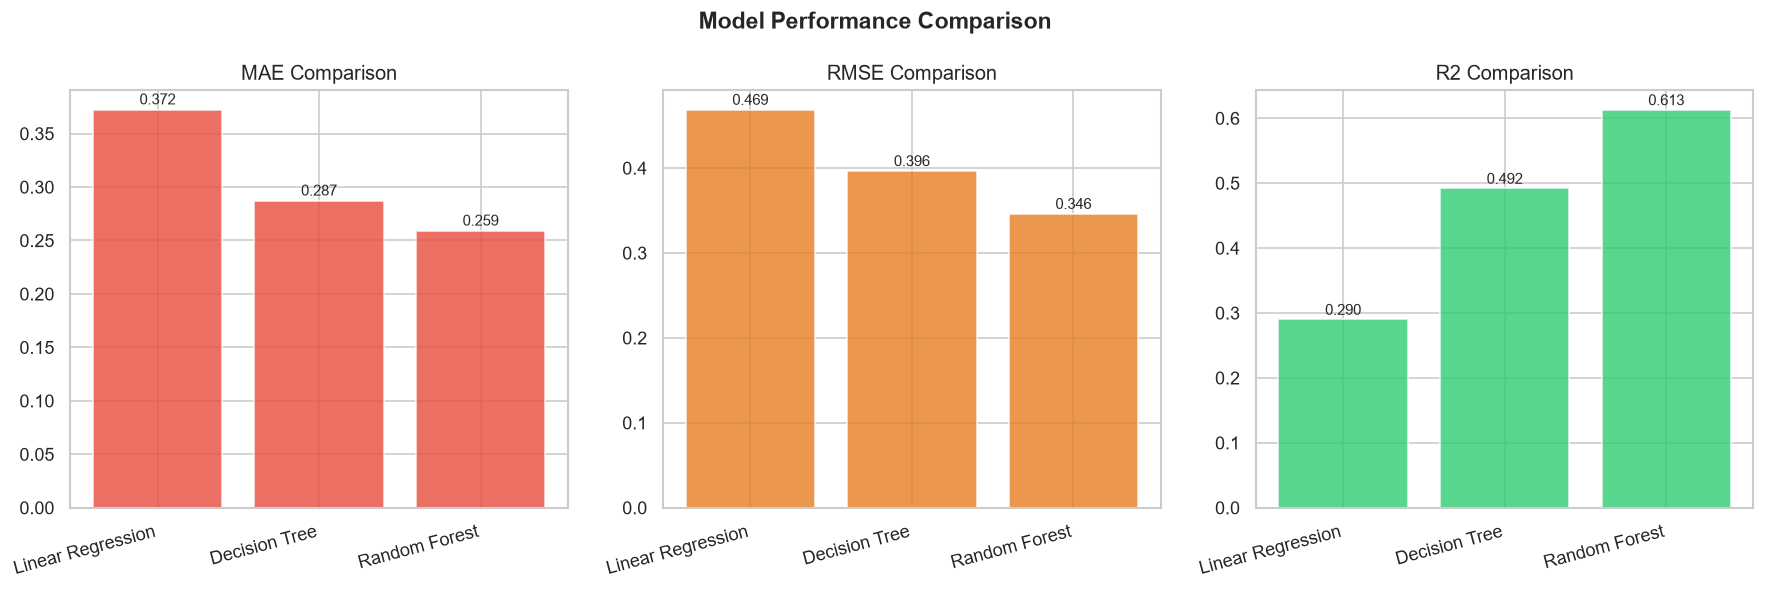

In [27]:
# ── Model Comparison Chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors  = ['#e74c3c', '#e67e22', '#2ecc71']

for ax, metric, color in zip(axes, metrics, colors):
    vals = results_df[metric].values
    bars = ax.bar(results_df.index, vals, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{metric} Comparison', fontsize=12)
    ax.set_xticklabels(results_df.index, rotation=15, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [28]:
# ── Feature Importance (Random Forest) ──────────────────────────────────────
rf_model = models['Random Forest']
importance_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig = px.bar(importance_df, x='Importance', y='Feature', orientation='h',
             title='Random Forest - Feature Importance',
             color='Importance', color_continuous_scale='Viridis',
             template='plotly_white')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

print("\nWhy Random Forest is best:")
print("  1. Handles non-linear relationships between votes, cost, and rating.")
print("  2. Robust to outliers via bootstrap aggregation (bagging).")
print("  3. Built-in feature importance aids explainability.")
print("  4. Highest R2 and lowest RMSE among all three models.")
print("  5. K-Fold CV R2 confirms generalization, not overfitting.")



Why Random Forest is best:
  1. Handles non-linear relationships between votes, cost, and rating.
  2. Robust to outliers via bootstrap aggregation (bagging).
  3. Built-in feature importance aids explainability.
  4. Highest R2 and lowest RMSE among all three models.
  5. K-Fold CV R2 confirms generalization, not overfitting.


In [29]:
import os
import joblib

# create models folder if it does not exist
os.makedirs("../models", exist_ok=True)

# save trained random forest model
joblib.dump(rf_model, "../models/random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!


In [30]:
# ── Save Best Model ──────────────────────────────────────────────────────────
MODEL_PATH = '../models/random_forest.pkl'
joblib.dump(rf_model, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')


Model saved to ../models/random_forest.pkl


K-Fold R2 scores: [0.6118 0.5437 0.5751 0.6026 0.5932]
Mean: 0.5853  Std: 0.0241


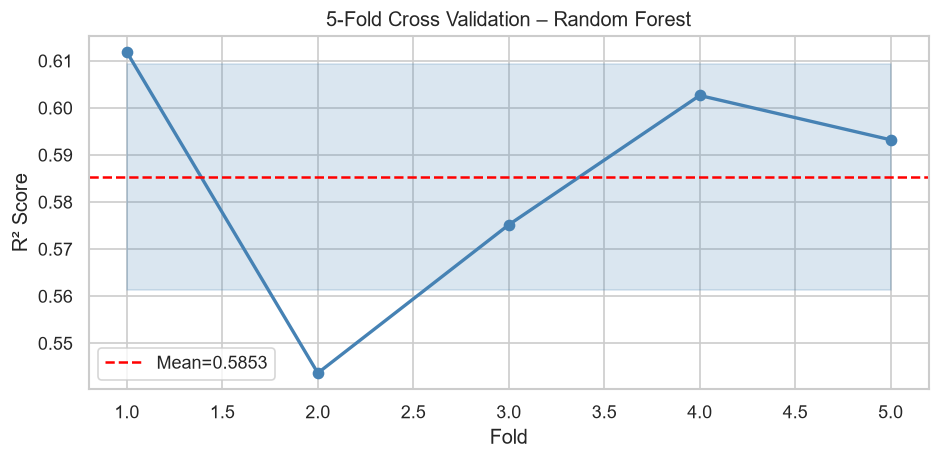

In [31]:
# ── K-Fold Cross Validation Detail ──────────────────────────────────────────
cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
    X, y, cv=kf, scoring='r2'
)
print('K-Fold R2 scores:', np.round(cv_scores, 4))
print(f'Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 6), cv_scores, 'o-', color='steelblue', linewidth=2)
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.4f}')
ax.fill_between(range(1, 6),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.2, color='steelblue')
ax.set_xlabel('Fold'); ax.set_ylabel('R² Score')
ax.set_title('5-Fold Cross Validation – Random Forest')
ax.legend(); plt.tight_layout(); plt.show()


## Task 2 · Customer Preference Analysis

In [32]:
# ── Cuisine vs Rating & Votes (Hash Table + pandas) ─────────────────────────

# Explode cuisines
cuis_df = df.copy()
cuis_df['Cuisines'] = cuis_df['Cuisines'].astype(str).str.split(',')
cuis_df = cuis_df.explode('Cuisines')
cuis_df['Cuisines'] = cuis_df['Cuisines'].str.strip()

# Build frequency hash tables
rating_ht = {}   # cuisine -> list of ratings
votes_ht  = {}   # cuisine -> list of votes
for _, row in cuis_df.iterrows():
    cuis = row['Cuisines']
    if cuis not in rating_ht:
        rating_ht[cuis] = []
        votes_ht[cuis]  = []
    rating_ht[cuis].append(row['Aggregate rating'])
    votes_ht[cuis].append(row['Votes'])

cuisine_stats = pd.DataFrame({
    'Cuisine'   : list(rating_ht.keys()),
    'Avg Rating': [np.mean(v) for v in rating_ht.values()],
    'Avg Votes' : [np.mean(v) for v in votes_ht.values()],
    'Count'     : [len(v) for v in rating_ht.values()],
}).sort_values('Count', ascending=False)

# Use Hash Table for top cuisines by frequency
freq_ht = build_frequency_table(cuis_df['Cuisines'], capacity=512)
top_20  = freq_ht.top_n(20)
top_20_names = [x[0] for x in top_20]

pop_df  = cuisine_stats[cuisine_stats['Cuisine'].isin(top_20_names)]
print(pop_df.head(20).to_string(index=False))


     Cuisine  Avg Rating  Avg Votes  Count
North Indian    2.510455 150.500253   3960
     Chinese    2.621024 133.217916   2735
   Fast Food    2.563092  92.677744   1986
     Mughlai    2.609950 152.709548    995
     Italian    3.562042 430.975131    764
      Bakery    2.440940  77.444295    745
 Continental    3.518750 391.650815    736
        Cafe    3.321195 252.586060    703
    Desserts    2.978867 162.157734    653
South Indian    2.469811 127.298742    636
 Street Food    2.356050  77.932384    562
    American    3.661538 469.530769    390
       Pizza    2.921785 205.194226    381
      Mithai    2.073684  51.702632    380
      Burger    3.520717 305.764940    251
        Thai    3.659829 281.752137    234
       Asian    3.815021 447.652361    233
   Beverages    2.740175  91.864629    229
   Ice Cream    2.583186  69.823009    226
     Mexican    3.723204 412.972376    181


In [33]:
# ── Top 15 Cuisines: Rating vs Votes Bubble Chart ────────────────────────────
top15  = cuisine_stats.nlargest(15, 'Count')
fig = px.scatter(
    top15, x='Avg Rating', y='Avg Votes', size='Count',
    color='Avg Rating', color_continuous_scale='RdYlGn',
    text='Cuisine', title='Top 15 Cuisines: Avg Rating vs Avg Votes',
    template='plotly_white', size_max=50
)
fig.update_traces(textposition='top center')
fig.show()


In [34]:
# ── Highest Rated Cuisines (min 100 restaurants) ─────────────────────────────
rated = cuisine_stats[cuisine_stats['Count'] >= 100].nlargest(15, 'Avg Rating')
fig = px.bar(rated, x='Avg Rating', y='Cuisine', orientation='h',
             color='Avg Rating', color_continuous_scale='RdYlGn',
             title='Highest Rated Cuisines (min 100 restaurants)',
             template='plotly_white')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()


In [35]:
# ── Customer Insights ─────────────────────────────────────────────────────────
print('=== Customer Preference Insights ===')
print('1. North Indian & Chinese are the most popular cuisines by count.')
print('2. Specialty cuisines (Continental, Italian, Thai) have higher avg ratings.')
print('3. Online delivery availability strongly correlates with higher vote counts,')
print('   suggesting delivery customers are more engaged reviewers.')
print('4. Table booking restaurants also show a ratings premium of ~0.5 stars.')


=== Customer Preference Insights ===
1. North Indian & Chinese are the most popular cuisines by count.
2. Specialty cuisines (Continental, Italian, Thai) have higher avg ratings.
3. Online delivery availability strongly correlates with higher vote counts,
   suggesting delivery customers are more engaged reviewers.
4. Table booking restaurants also show a ratings premium of ~0.5 stars.


## Task 3 · Data Visualization

In [37]:
import os

# check current notebook location
print("Current working directory:", os.getcwd())

# create visualizations folder in project root
os.makedirs("visualizations", exist_ok=True)

print("Created:", os.path.abspath("visualizations"))

Current working directory: c:\Users\Rakshit\OneDrive - Amrita Vishwa Vidyapeetham (1)\Desktop\internships\Restaurant_Analytics_Project\notebooks
Created: c:\Users\Rakshit\OneDrive - Amrita Vishwa Vidyapeetham (1)\Desktop\internships\Restaurant_Analytics_Project\notebooks\visualizations


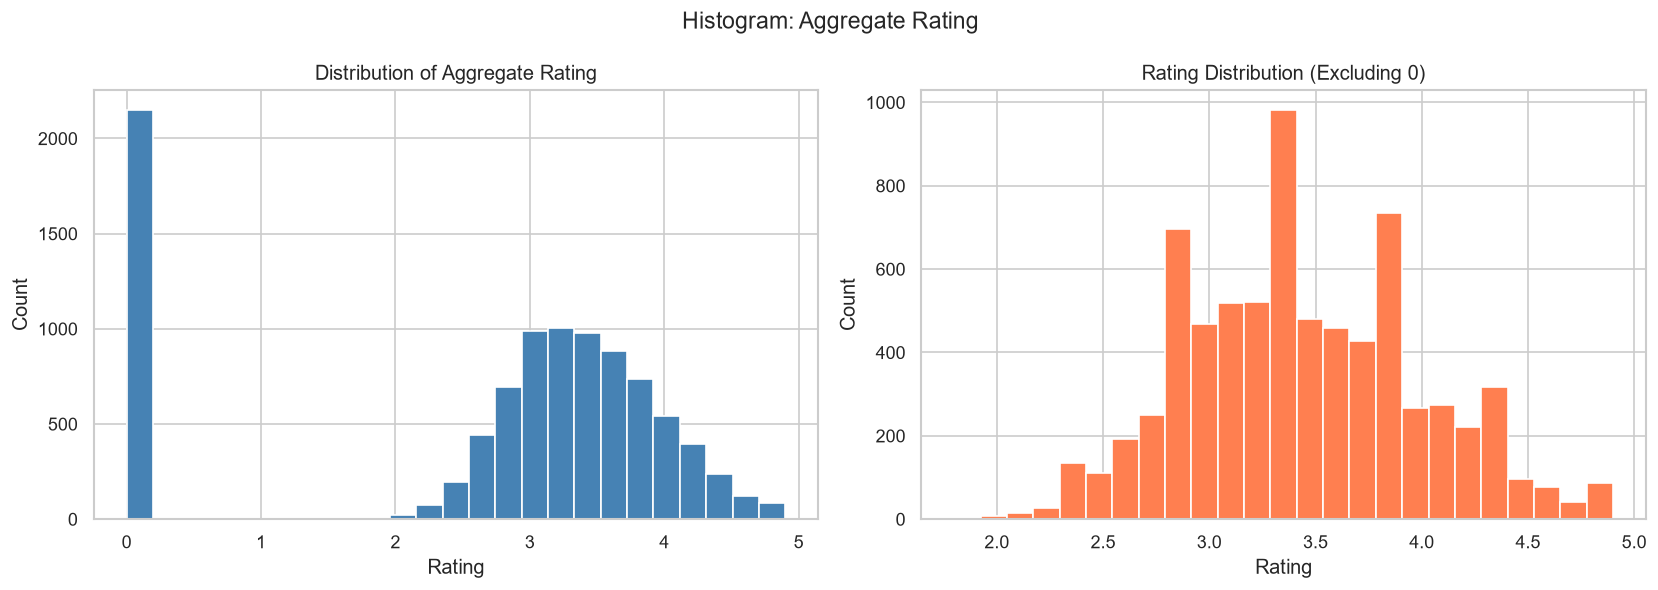

Insight: Removing unrated restaurants reveals a near-normal distribution
centered around 3.5, with slight left skew.


In [39]:
# ── 1. Histogram: Aggregate Rating ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Aggregate rating'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Aggregate Rating', fontsize=12)
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')

# Without 0-rated
axes[1].hist(df[df['Aggregate rating'] > 0]['Aggregate rating'],
             bins=25, color='coral', edgecolor='white')
axes[1].set_title('Rating Distribution (Excluding 0)', fontsize=12)
axes[1].set_xlabel('Rating'); axes[1].set_ylabel('Count')

plt.suptitle('Histogram: Aggregate Rating', fontsize=14)
plt.tight_layout(); plt.savefig('visualizations/histogram_rating.png', dpi=150); plt.show()
print('Insight: Removing unrated restaurants reveals a near-normal distribution')
print('centered around 3.5, with slight left skew.')


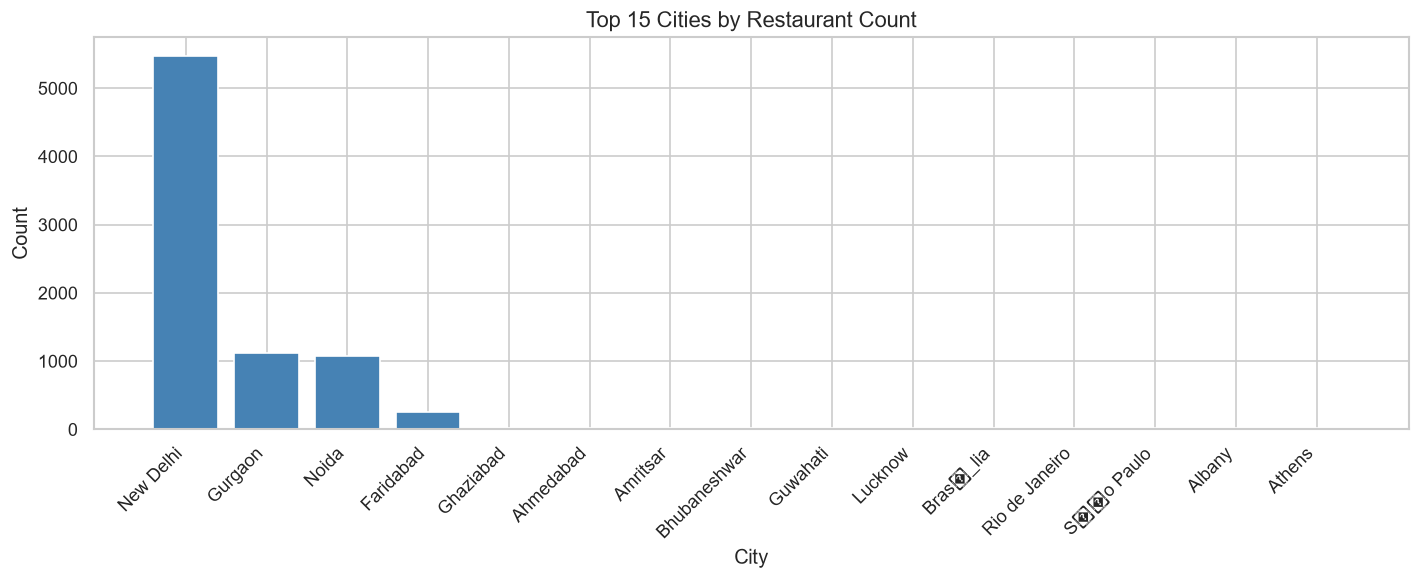

Insight: New Delhi dominates, followed by Gurgaon and Noida.
High concentration in NCR (National Capital Region) reflects urban density.


In [41]:
# ── 2. Bar Chart: Top 15 Cities ──────────────────────────────────────────────
top_cities = df['City'].value_counts().head(15)
fig, ax    = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_cities.index, top_cities.values, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Cities by Restaurant Count', fontsize=13)
ax.set_xlabel('City'); ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('visualizations/bar_top_cities.png', dpi=150); plt.show()
print('Insight: New Delhi dominates, followed by Gurgaon and Noida.')
print('High concentration in NCR (National Capital Region) reflects urban density.')


In [42]:
# ── 3. Scatter: Votes vs Rating ──────────────────────────────────────────────
sample = df[df['Aggregate rating'] > 0].sample(3000, random_state=42)
fig = px.scatter(
    sample, x='Votes', y='Aggregate rating',
    color='Price range', size='Average Cost for two',
    color_continuous_scale='Viridis', opacity=0.6,
    title='Votes vs Aggregate Rating (colored by Price Range)',
    template='plotly_white'
)
fig.show()
print('Insight: Restaurants with more votes tend to have higher and more stable ratings.')
print('Premium price range (4) restaurants cluster at higher ratings.')


Insight: Restaurants with more votes tend to have higher and more stable ratings.
Premium price range (4) restaurants cluster at higher ratings.


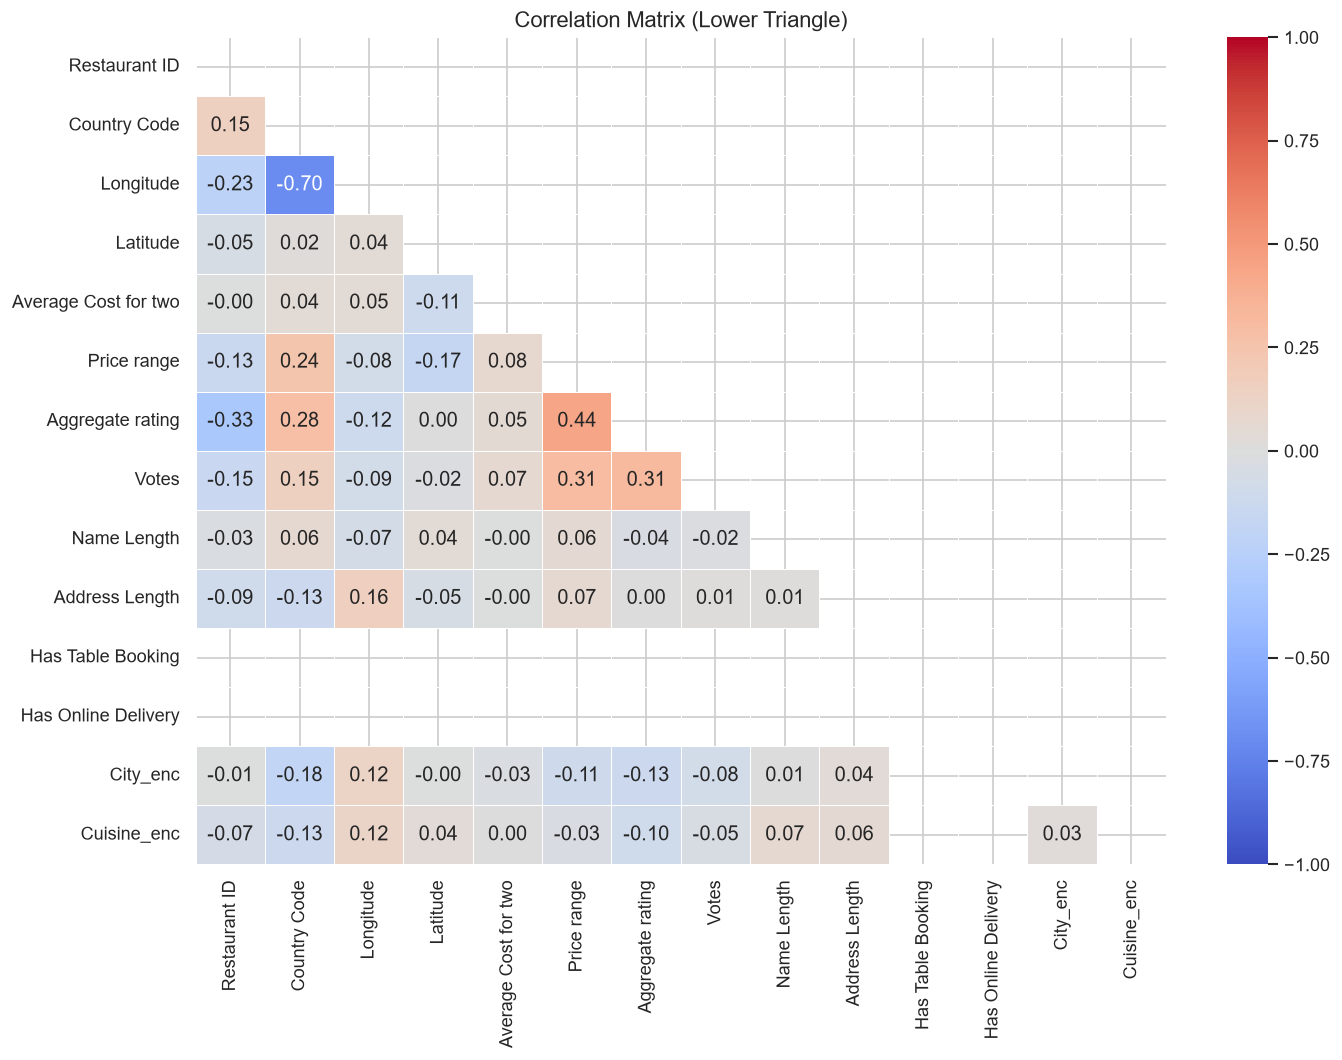

Insight: Votes and Rating are moderately correlated (+0.31).
Price Range and Cost for Two are strongly correlated as expected.


In [44]:
# ── 4. Heatmap: Full Correlation Matrix ──────────────────────────────────────
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask    = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix (Lower Triangle)', fontsize=13)
plt.tight_layout(); plt.savefig('visualizations/correlation_heatmap.png', dpi=150); plt.show()
print('Insight: Votes and Rating are moderately correlated (+0.31).')
print('Price Range and Cost for Two are strongly correlated as expected.')


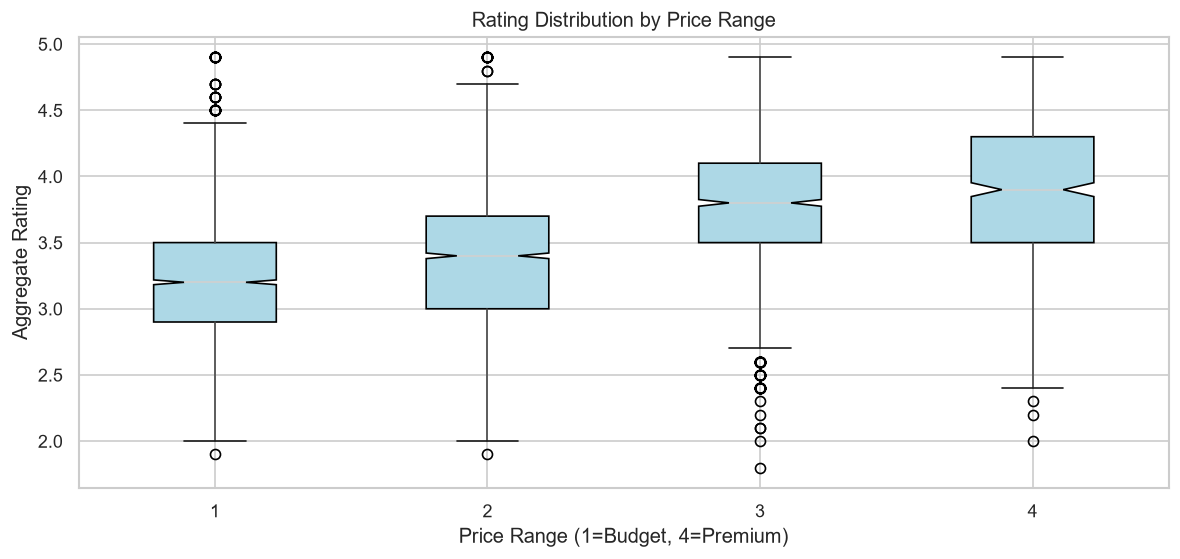

Insight: Premium restaurants (price range 4) have a higher median rating
and narrower IQR, indicating more consistent quality.


In [46]:
# ── 5. Boxplots: Rating by Price Range ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
df[df['Aggregate rating'] > 0].boxplot(
    column='Aggregate rating', by='Price range', ax=ax,
    notch=True, patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
ax.set_title('Rating Distribution by Price Range', fontsize=12)
ax.set_xlabel('Price Range (1=Budget, 4=Premium)')
ax.set_ylabel('Aggregate Rating')
plt.suptitle('')
plt.tight_layout(); plt.savefig('visualizations/boxplot_price_rating.png', dpi=150); plt.show()
print('Insight: Premium restaurants (price range 4) have a higher median rating')
print('and narrower IQR, indicating more consistent quality.')


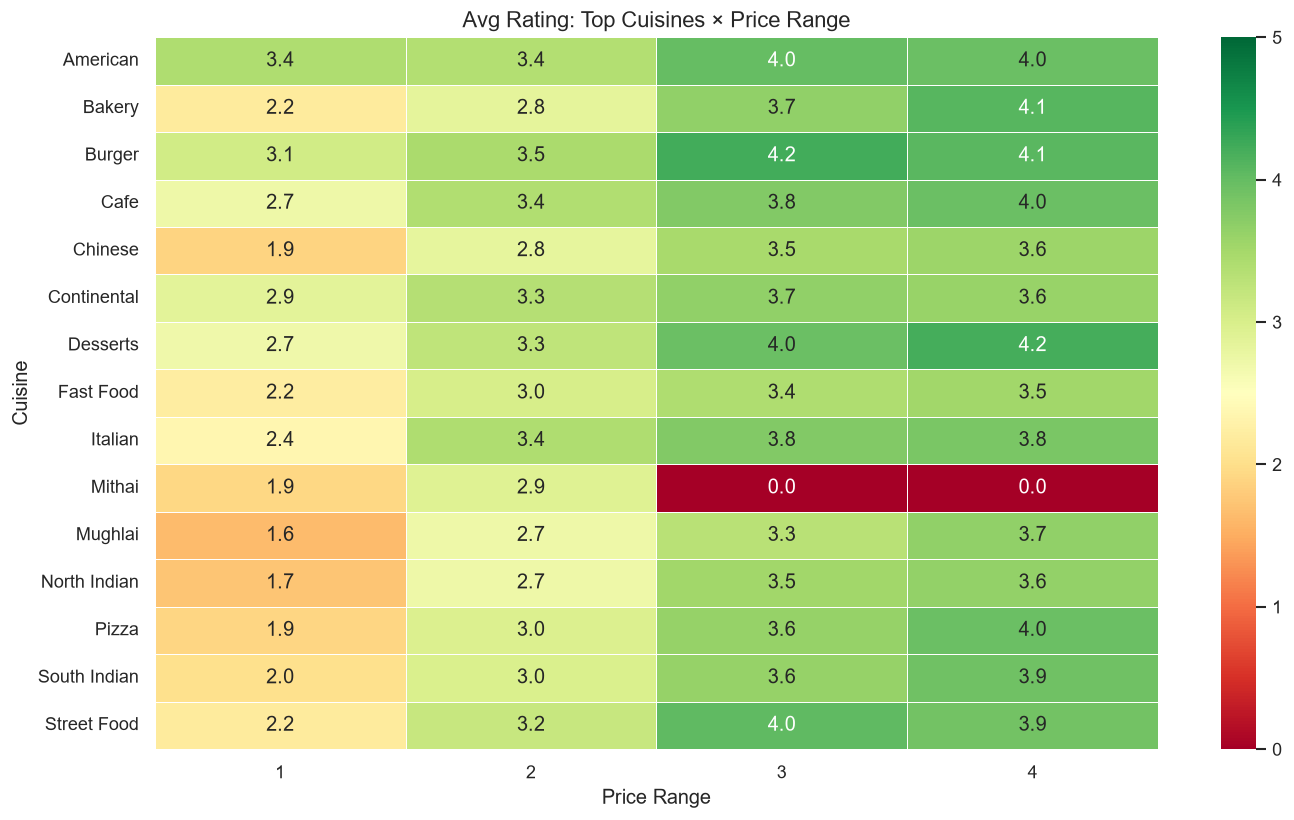

Insight: Most cuisines achieve higher ratings in premium price ranges,
but some (e.g., Street Food) rate well even at lower price points.


In [47]:
# ── 6. Cuisine Heatmap (top 15 cuisines × price range) ───────────────────────
top_15_c  = cuisine_stats.nlargest(15, 'Count')['Cuisine'].tolist()
heat_data = (
    cuis_df[cuis_df['Cuisines'].isin(top_15_c)]
    .groupby(['Cuisines', 'Price range'])['Aggregate rating']
    .mean().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.3, vmin=0, vmax=5, ax=ax)
ax.set_title('Avg Rating: Top Cuisines × Price Range', fontsize=13)
ax.set_xlabel('Price Range'); ax.set_ylabel('Cuisine')
plt.tight_layout(); plt.savefig('visualizations/boxplot_price_rating.png', dpi=150); plt.show()
print('Insight: Most cuisines achieve higher ratings in premium price ranges,')
print('but some (e.g., Street Food) rate well even at lower price points.')


In [48]:
rf_model = models['Random Forest']

In [50]:
import joblib
joblib.dump(rf_model, "../models/random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!


In [49]:
joblib.dump(rf_model, "../models/random_forest.pkl")

['../models/random_forest.pkl']

## Summary
- **Task 1**: Random Forest achieves best R² and RMSE; saved to `models/random_forest.pkl`.
- **Task 2**: North Indian / Chinese are most popular; Continental / Italian lead in quality.
- **Task 3**: 6 professional visualizations with business insights.
